# **MÉTODOS DE REPRESENTACIÓN TRADICIONALES**

# **TF-IDF**

In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA, TruncatedSVD
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.manifold import TSNE
import pickle
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

In [ ]:
DATA_PATH = "processed_data/preprocNoContext.parquet"
TFIDF_DIR = Path("embeddings/repTrad/TF-IDF")
BOW_DIR = Path("embeddings/repTrad/BOW")

In [ ]:
data = pd.read_parquet("processed_data/preprocNoContext.parquet")

print(f"\nDocumentos: {len(data)}")
data.head(5)


Documentos: 5160


,ticker,headline,summary,article_text,topic,noContextText
0,AAPL,UK pay growth slows and unemployment ticks hig...,The UK jobs market continues to show signs of ...,The UK jobs market continues to show signs of ...,Financial and Market News and Corporate Sales,uk job market continue sign weakness pay growt...
1,AAPL,Rising pension age hits women hardest,Enabling people to work for longer can spell g...,New data from the Department from Work and Pen...,Informal / Conversational Lenguaje,new datum department work pension work pattern...
2,AAPL,How to ask for changes at work if you are neur...,Advocating for yourself can help create a cult...,Asking for workplace accommodations is often e...,Informal / Conversational Lenguaje,ask workplace accommodation easy people worry ...
3,AAPL,Apple announces major expansion of renewables ...,The tech giant has increased its involvement i...,Apple has announced a major expansion of its r...,Financial and Market News and Corporate Sales,apple announce major expansion renewable inves...
4,AAPL,"1 Unstoppable Stock Poised to Join Nvidia, App...",Semiconductors form the foundation of the arti...,The advent of artificial intelligence (AI) les...,Business Growth and Cloud Infrastructure in th...,advent artificial intelligence ai year ago spa...


In [59]:
data_clean = data[data["noContextText"].notna() & (data["noContextText"].str.len() > 0)].copy()
print(f"Documentos válidos después de limpieza: {len(data_clean)}")

corpus = data_clean["noContextText"].tolist()

Documentos válidos después de limpieza: 5160


### Crear el vectorizer TF-IDF

In [60]:
tfidf_vectorizer = TfidfVectorizer(
    min_df=2,              # Ignorar términos en menos de 2 docs
    max_df=0.8,            # Ignorar términos en más del 80% de docs
    ngram_range=(1, 2),    # Unigramas y bigramas
    max_features=5000,     # Top 5000 características
    norm='l2',             # Normalización L2
    use_idf=True,          # Usar IDF
    sublinear_tf=True
)

In [61]:
tfidf_matrix = tfidf_vectorizer.fit_transform(corpus)
print(f"Matriz TF-IDF creada: {tfidf_matrix.shape}")
print(f"  - Documentos: {tfidf_matrix.shape[0]}")
print(f"  - Características: {tfidf_matrix.shape[1]}")
print(f"  - Sparsity: {1 - (tfidf_matrix.nnz / (tfidf_matrix.shape[0] * tfidf_matrix.shape[1])):.4f}")

Matriz TF-IDF creada: (5160, 5000)
  - Documentos: 5160
  - Características: 5000
  - Sparsity: 0.9651


In [44]:
tfidf_vectorizer_path = TFIDF_DIR / "tfidf_vectorizer.pkl"
with open(tfidf_vectorizer_path, "wb") as f:
    pickle.dump(tfidf_vectorizer, f)
print(f"Guardado:{tfidf_vectorizer_path}")

Guardado:embeddings\repTrad\TF-IDF\tfidf_vectorizer.pkl


# **BAG OF WORDS (BOW)**

## CREAR EMBEDDINGS BOW

Para esto hemos considerado un umbral mínimo de aparición (`min_df=2`) para eliminar términos residuales y un máximo (`max_df=0.8`) para descartar palabras demasiado frecuentes que no aportan información. Además, incluimos unigramas y bigramas que por lo general suelen ser las combinaciones relevantes en cuanto a lo financiero (p. ej., *interest rate*, *stock market*), y limitamos las características a las 5000 más representativas para mantener un equilibrio entre cobertura y eficiencia computacional.


In [62]:
bow_vectorizer = CountVectorizer(
    min_df=2,              # Ignorar términos en menos de 2 docs
    max_df=0.8,            # Ignorar términos en más del 80% de docs
    ngram_range=(1, 2),    # Unigramas y bigramas
    max_features=5000,     # Top 5000 características
    binary=False           # Usar frecuencias (no binario)
)

bow_matrix = bow_vectorizer.fit_transform(corpus)
print(f"Matriz BoW creada: {bow_matrix.shape}")
print(f"  - Documentos: {bow_matrix.shape[0]}")
print(f"  - Características: {bow_matrix.shape[1]}")
print(f"  - Sparsity: {1 - (bow_matrix.nnz / (bow_matrix.shape[0] * bow_matrix.shape[1])):.4f}")

Matriz BoW creada: (5160, 5000)
  - Documentos: 5160
  - Características: 5000
  - Sparsity: 0.9651


In [63]:
bow_vectorizer_path = BOW_DIR / "bow_vectorizer.pkl"
with open(bow_vectorizer_path, "wb") as f:
    pickle.dump(bow_vectorizer, f)
print(f"Guardado: {bow_vectorizer_path}")

Guardado: embeddings\repTrad\BOW\bow_vectorizer.pkl


# **ANÁLISIS DE RESULTADOS Y COMPARACIONES**

### **TF-IDF**

In [55]:
TFIDF_DIR = Path("embeddings/repTrad/TF-IDF")
with open(TFIDF_DIR / "tfidf_vectorizer.pkl", "rb") as f:
    tfidf_vectorizer = pickle.load(f)

tfidf_matrix = tfidf_vectorizer.transform(corpus)

print(f"\n - Dimensiones de la matriz TF-IDF: {tfidf_matrix.shape}")
print(f"   - Documentos: {tfidf_matrix.shape[0]:,}")
print(f"   - Features (vocabulario): {tfidf_matrix.shape[1]:,}")
print(f"   - Sparsity: {1 - (tfidf_matrix.nnz / (tfidf_matrix.shape[0] * tfidf_matrix.shape[1])):.4f}")
print(f"   - Elementos no-cero: {tfidf_matrix.nnz:,}")


 - Dimensiones de la matriz TF-IDF: (5160, 5000)
   - Documentos: 5,160
   - Features (vocabulario): 5,000
   - Sparsity: 0.9651
   - Elementos no-cero: 900,023


### DISTRIBUCIÓN DE VALORES

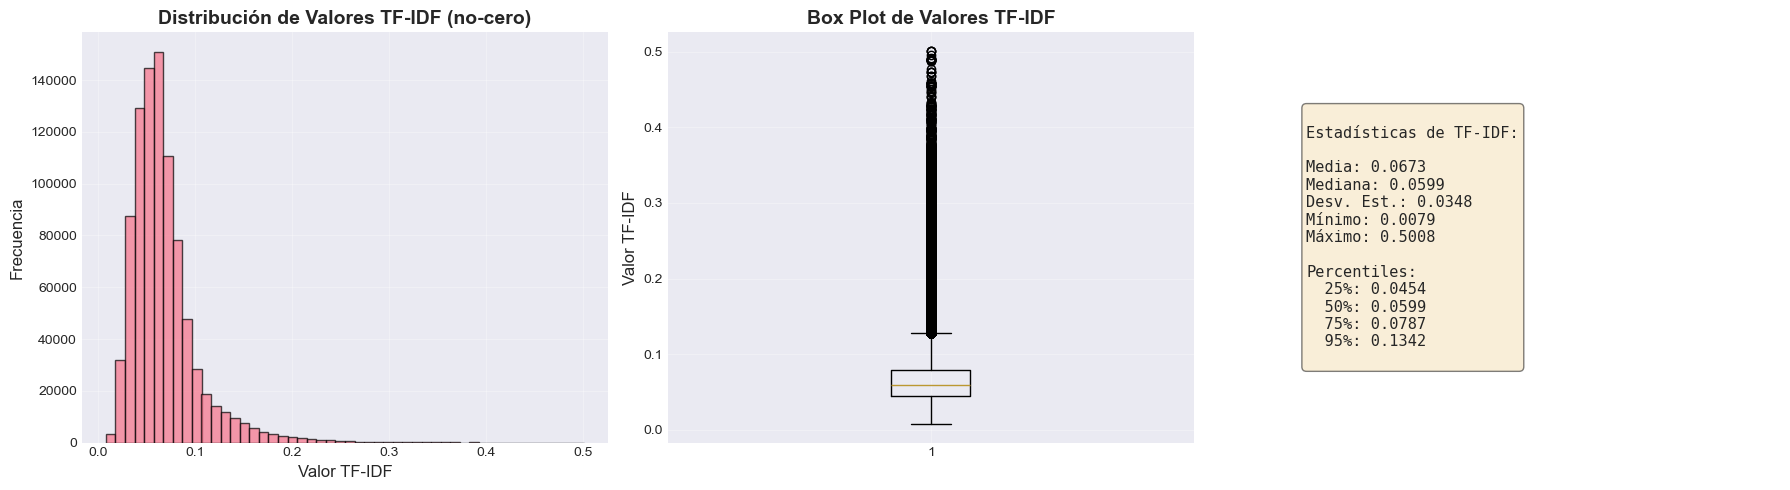


Media de valores TF-IDF: 0.0673
Mediana: 0.0599


In [24]:
non_zero_values = tfidf_matrix.data
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].hist(non_zero_values, bins=50, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Valor TF-IDF', fontsize=12)
axes[0].set_ylabel('Frecuencia', fontsize=12)
axes[0].set_title('Distribución de Valores TF-IDF (no-cero)', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[1].boxplot(non_zero_values, vert=True)
axes[1].set_ylabel('Valor TF-IDF', fontsize=12)
axes[1].set_title('Box Plot de Valores TF-IDF', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)

# Estadísticas básicas
stats_text = f"""
Estadísticas de TF-IDF:

Media: {np.mean(non_zero_values):.4f}
Mediana: {np.median(non_zero_values):.4f}
Desv. Est.: {np.std(non_zero_values):.4f}
Mínimo: {np.min(non_zero_values):.4f}
Máximo: {np.max(non_zero_values):.4f}

Percentiles:
  25%: {np.percentile(non_zero_values, 25):.4f}
  50%: {np.percentile(non_zero_values, 50):.4f}
  75%: {np.percentile(non_zero_values, 75):.4f}
  95%: {np.percentile(non_zero_values, 95):.4f}
"""

axes[2].text(0.1, 0.5, stats_text, fontsize=11, family='monospace',
             verticalalignment='center', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
axes[2].axis('off')

plt.tight_layout()
plt.savefig('analisis_distribucion_tfidf.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nMedia de valores TF-IDF: {np.mean(non_zero_values):.4f}")
print(f"Mediana: {np.median(non_zero_values):.4f}")

La distribución de los valores TF-IDF muestra una clara concentración en rangos bajos (media ≈ 0.067 y mediana ≈ 0.060), lo que indica que la mayoría de los términos tienen una relevancia moderada dentro del corpus. Intepretamos que esto es normal en textos amplios, donde solo una pequeña proporción de palabras adquiere pesos altos por su especificidad contextual. La presencia de algunos valores atípicos confirma que el modelo logra distinguir términos verdaderamente distintivos en nuestro dominio

### TERMINOS MÁS/MENOS COMUNES

Analizamos los términos más frecuentes y los más raros según su peso IDF. Este paso permite identificar las palabras que dominan el corpus frente a aquellas más informativas o especializadas. Nos sirve también para comprobar la coherencia temática y la presencia de vocabulario financiero relevante.

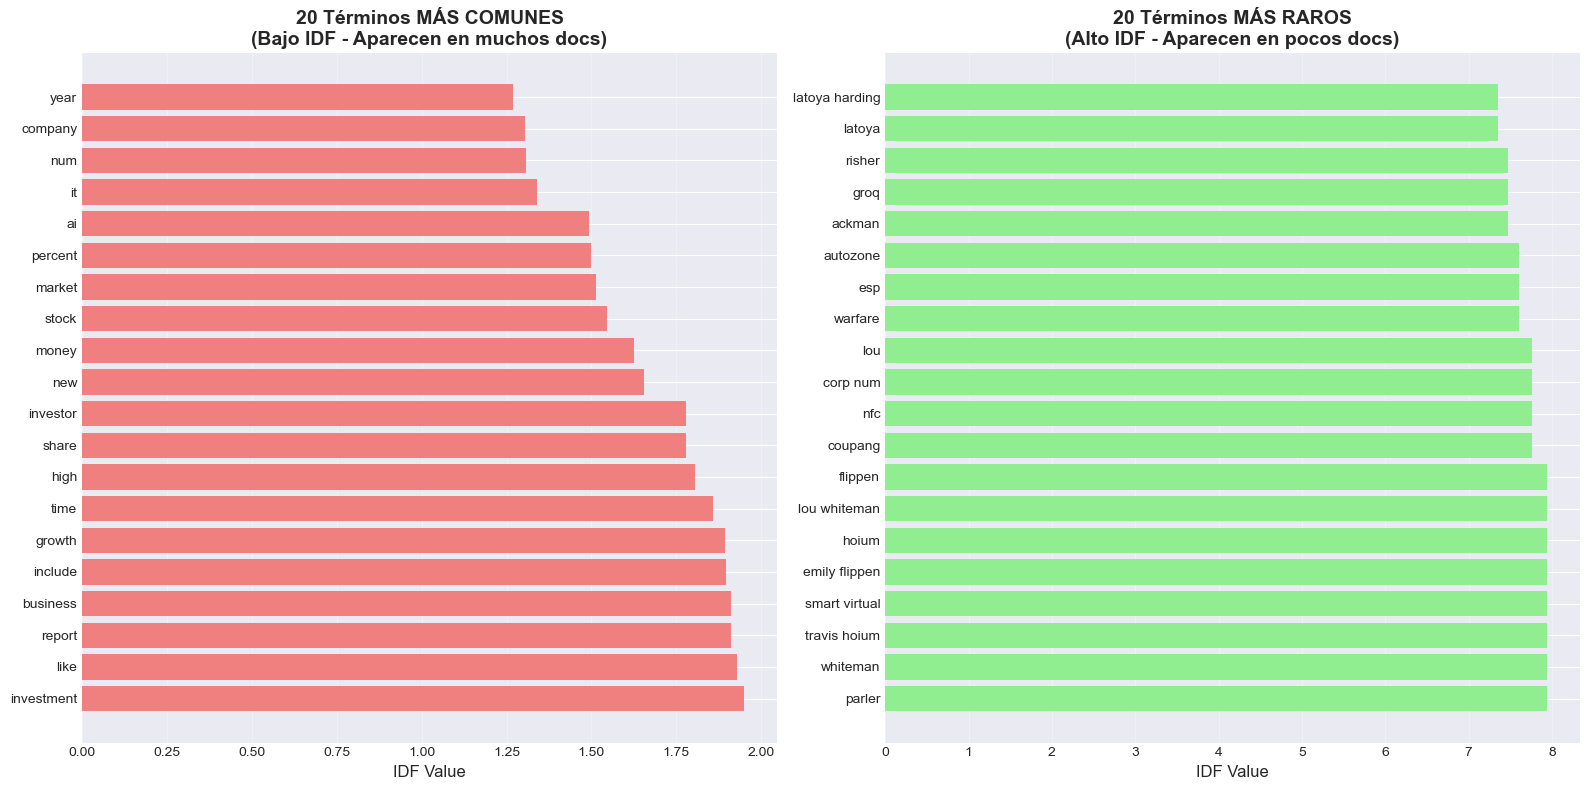


📋 Top 10 términos más comunes:
   year                      IDF: 1.2694
   company                   IDF: 1.3030
   num                       IDF: 1.3064
   it                        IDF: 1.3388
   ai                        IDF: 1.4921
   percent                   IDF: 1.4991
   market                    IDF: 1.5146
   stock                     IDF: 1.5469
   money                     IDF: 1.6255
   new                       IDF: 1.6546


In [ ]:
feature_names = np.array(tfidf_vectorizer.get_feature_names_out())
idf_values = tfidf_vectorizer.idf_

# Términos más comunes (bajo IDF = aparecen en muchos docs)
most_common_idx = np.argsort(idf_values)[:20]
most_common_terms = feature_names[most_common_idx]
most_common_idf = idf_values[most_common_idx]

# Términos más raros (alto IDF = aparecen en pocos docs)
most_rare_idx = np.argsort(idf_values)[-20:][::-1]
most_rare_terms = feature_names[most_rare_idx]
most_rare_idf = idf_values[most_rare_idx]

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

axes[0].barh(range(20), most_common_idf[::-1], color='lightcoral')
axes[0].set_yticks(range(20))
axes[0].set_yticklabels(most_common_terms[::-1], fontsize=10)
axes[0].set_xlabel('IDF Value', fontsize=12)
axes[0].set_title('20 Términos MÁS COMUNES\n(Bajo IDF - Aparecen en muchos docs)', 
                  fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='x')
axes[1].barh(range(20), most_rare_idf, color='lightgreen')
axes[1].set_yticks(range(20))
axes[1].set_yticklabels(most_rare_terms, fontsize=10)
axes[1].set_xlabel('IDF Value', fontsize=12)
axes[1].set_title('20 Términos MÁS RAROS\n(Alto IDF - Aparecen en pocos docs)', 
                  fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('analisis_terminos_idf.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nTop 10 términos más comunes:")
for term, idf in zip(most_common_terms[:10], most_common_idf[:10]):
    print(f"   {term:<25} IDF: {idf:.4f}")

## BAG OF WORDS

In [ ]:
from pathlib import Path
import pickle
import numpy as np
import matplotlib.pyplot as plt

BOW_DIR = Path("embeddings/repTrad/BOW")

with open(BOW_DIR / "bow_vectorizer.pkl", "rb") as f:
    bow_vectorizer = pickle.load(f)
bow_matrix = bow_vectorizer.transform(corpus)

print(f"\n - Dimensiones de la matriz BoW: {bow_matrix.shape}")
print(f"   - Documentos: {bow_matrix.shape[0]:,}")
print(f"   - Features (vocabulario): {bow_matrix.shape[1]:,}")
print(f"   - Sparsity: {1 - (bow_matrix.nnz / (bow_matrix.shape[0] * bow_matrix.shape[1])):.4f}")
print(f"   - Elementos no-cero: {bow_matrix.nnz:,}")


 - Dimensiones de la matriz BoW: (5160, 5000)
   - Documentos: 5,160
   - Features (vocabulario): 5,000
   - Sparsity: 0.9651
   - Elementos no-cero: 900,023


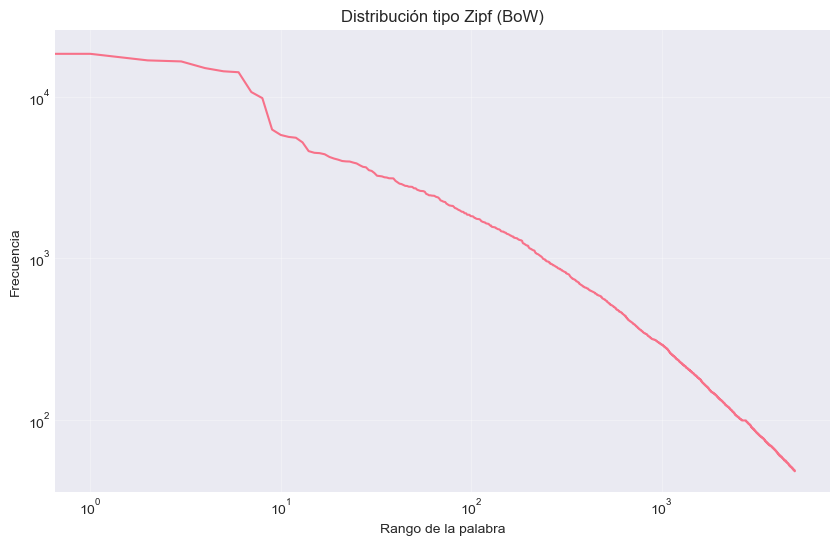

In [71]:
term_frequencies = np.asarray(bow_matrix.sum(axis=0)).ravel()
sorted_freqs = np.sort(term_frequencies)[::-1]

plt.figure(figsize=(10,6))
plt.plot(sorted_freqs)
plt.yscale('log')
plt.xscale('log')
plt.xlabel('Rango de la palabra')
plt.ylabel('Frecuencia')
plt.title('Distribución tipo Zipf (BoW)')
plt.grid(True, alpha=0.3)
plt.show()


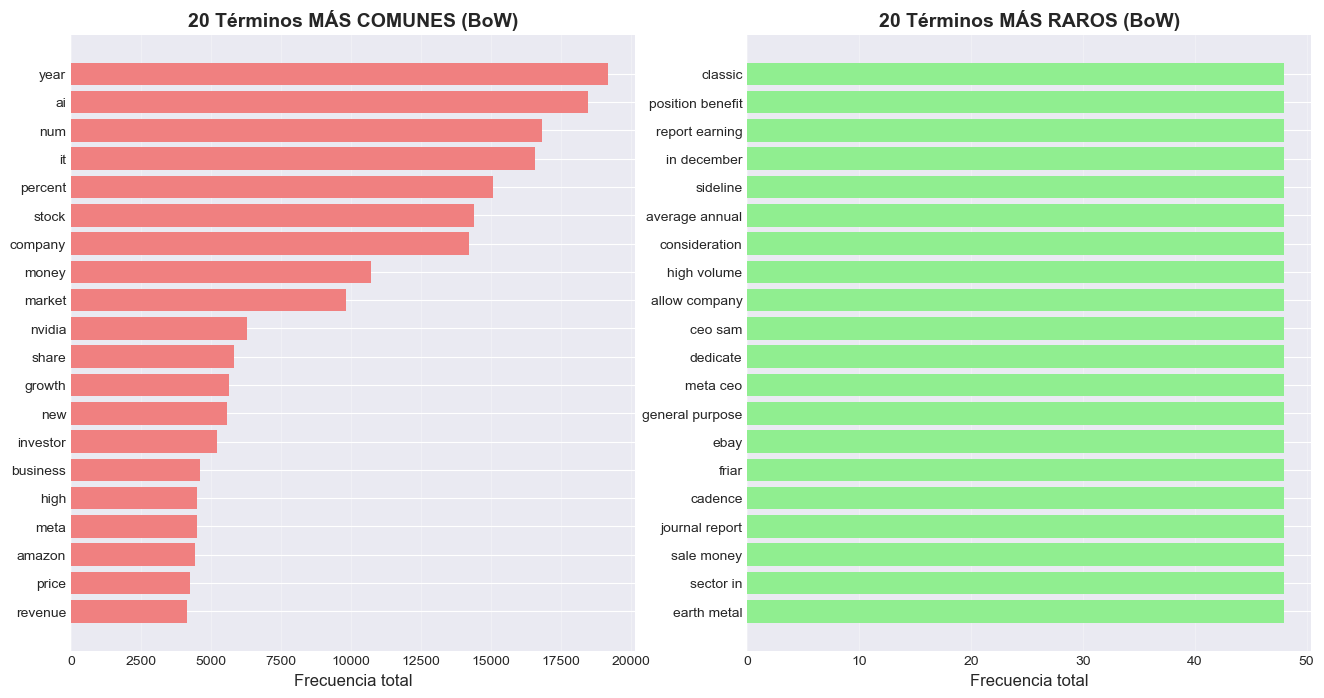

In [ ]:
feature_names = np.array(bow_vectorizer.get_feature_names_out())
term_frequencies = np.asarray(bow_matrix.sum(axis=0)).ravel()
most_common_idx = np.argsort(term_frequencies)[-20:][::-1]
most_common_terms = feature_names[most_common_idx]
most_common_freq = term_frequencies[most_common_idx]

most_rare_idx = np.argsort(term_frequencies)[:20]
most_rare_terms = feature_names[most_rare_idx]
most_rare_freq = term_frequencies[most_rare_idx]

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

axes[0].barh(range(20), most_common_freq[::-1], color='lightcoral')
axes[0].set_yticks(range(20))
axes[0].set_yticklabels(most_common_terms[::-1], fontsize=10)
axes[0].set_xlabel('Frecuencia total', fontsize=12)
axes[0].set_title('20 Términos MÁS COMUNES (BoW)', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='x')

axes[1].barh(range(20), most_rare_freq, color='lightgreen')
axes[1].set_yticks(range(20))
axes[1].set_yticklabels(most_rare_terms, fontsize=10)
axes[1].set_xlabel('Frecuencia total', fontsize=12)
axes[1].set_title('20 Términos MÁS RAROS (BoW)', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='x')

## COSINE SIMILARITY COMPARISON

Calculamos la similitud coseno entre los primeros documentos del corpus para observar si la representación TF-IDF agrupa correctamente textos de temáticas similares. Valores altos entre documentos relacionados confirman que el modelo capta patrones léxicos coherentes con el dominio económico.


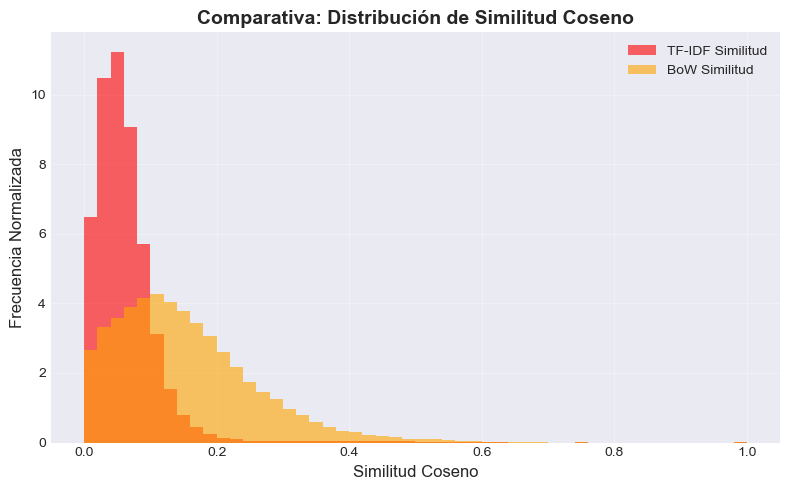


--- RESUMEN COMPARATIVO DE SIMILITUD (COSENO) ---
TF-IDF Similitud Media: 0.0639, Mediana: 0.0541
BoW Similitud Media: 0.1535, Mediana: 0.1352


In [ ]:
#Lo hemos hecho solo con 500 por agilizar
n_docs_to_sample = 500
np.random.seed(42)

n_sample = min(n_docs_to_sample, tfidf_matrix.shape[0])
sample_indices = np.random.choice(tfidf_matrix.shape[0], n_sample, replace=False)

# TF-IDF Similitud
tfidf_sample = tfidf_matrix[sample_indices]
tfidf_sim_matrix = cosine_similarity(tfidf_sample)
tfidf_tri_indices = np.triu_indices_from(tfidf_sim_matrix, k=1)
tfidf_similarity_values = tfidf_sim_matrix[tfidf_tri_indices]

# BoW Similitud
bow_sample = bow_matrix[sample_indices]
bow_sim_matrix = cosine_similarity(bow_sample)
bow_tri_indices = np.triu_indices_from(bow_sim_matrix, k=1)
bow_similarity_values = bow_sim_matrix[bow_tri_indices]


fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(tfidf_similarity_values, bins=50, density=True, alpha=0.6, label='TF-IDF Similitud', color='red')
ax.hist(bow_similarity_values, bins=50, density=True, alpha=0.6, label='BoW Similitud', color='orange')
ax.set_title('Comparativa: Distribución de Similitud Coseno', fontsize=14, fontweight='bold')
ax.set_xlabel('Similitud Coseno', fontsize=12)
ax.set_ylabel('Frecuencia Normalizada', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\n--- RESUMEN COMPARATIVO DE SIMILITUD (COSENO) ---")
print(f"TF-IDF Similitud Media: {np.mean(tfidf_similarity_values):.4f}, Mediana: {np.median(tfidf_similarity_values):.4f}")
print(f"BoW Similitud Media: {np.mean(bow_similarity_values):.4f}, Mediana: {np.median(bow_similarity_values):.4f}")

Los resultados del TF-IDF muestran que hemos generado un espacio vectorial consistente y representativo del corpus financiero. El modelo logra un equilibrio entre cobertura y especificidad, reduciendo la redundancia estadística y preservando las relaciones semánticas necesarias para tareas posteriores de clasificación o análisis temático.
